# Mental Health Early Warning System  
**Introduction:**
Mental health decline often goes unnoticed until it's too late. This study aims to develop a predictive model to identify individuals at risk of coping struggles using psychological, behavioral, and linguistic indicators.  

## Why It Matters  
- **Early Detection**: Timely interventions can prevent worsening mental health.  
- **Data-Driven Insights**: Analyzing patterns in stress, social behavior, and sentiment can improve mental health support.  

## Key Features for Prediction  
- **Growing Stress**: Increasing stress levels.  
- **Changes in Habits**: Sudden behavioral shifts.  
- **Days Indoors**: Social withdrawal tendencies.  
- **Mood Swings**: Emotional instability.  
- **Work Interest Decline**: Reduced productivity.  
- **Social Weakness**: Difficulty in interactions.  

## Dataset Overview  
The dataset includes text-based, sentiment, and psychological indicators such as stress, isolation, and emotional shifts. It provides a foundation for analyzing mental health trends in online communication.  

## Explainability (SHAP/LIME)  
To ensure model transparency, SHAP and LIME will highlight the most influential factors in predicting mental health struggles, enabling personalized intervention strategies.  

This research aims to create a proactive system for mental health monitoring, promoting timely support and well-being.


# Machine Learning Models for Mental Health Prediction

## **1. Importing Necessary Libraries**
We start by importing essential libraries for data handling, visualization, and machine learning.

- **`pandas` & `numpy`**: Used for data manipulation and numerical operations.
- **`matplotlib.pyplot` & `seaborn`**: For data visualization to analyze trends and model performance.

```python
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
```

## **2. Model Evaluation & Preprocessing**
To ensure reliable model performance, we use various evaluation techniques:

- **Metrics for Performance**:  
  - `accuracy_score`: Measures overall classification accuracy.  
  - `confusion_matrix`: Evaluates model performance across classes.  
  - `classification_report`: Provides precision, recall, and F1-score.

- **Data Preprocessing & Splitting**:  
  - `LabelEncoder`: Converts categorical features into numerical format.  
  - `StandardScaler`: Standardizes numerical data to improve model performance.  
  - `train_test_split`: Splits the dataset into training and testing sets.

- **Cross-validation techniques**:  
  - `RepeatedStratifiedKFold` & `StratifiedKFold`: Ensure fair training/testing data distribution.  
  - `cross_val_score`: Assesses model performance across multiple data splits.  
  - `GridSearchCV`: Tunes hyperparameters to optimize model performance.

```python
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split, RepeatedStratifiedKFold, cross_val_score, StratifiedKFold, GridSearchCV
```


## **3. Testing Multiple Machine Learning Models**
We will test different machine learning classifiers to determine which model performs best for predicting mental health struggles. The models include:

### **Traditional Machine Learning Models**
- **Linear Models**:
  - `LogisticRegression`: Works well for binary classification tasks.

- **Tree-Based Models**:
  - `DecisionTreeClassifier`: Simple and interpretable but prone to overfitting.
  - `RandomForestClassifier`: An ensemble of decision trees, reducing overfitting.
  - `ExtraTreesClassifier`: A variation of random forests with additional randomness.

- **Instance-Based Learning**:
  - `KNeighborsClassifier`: Classifies based on the closest data points.
  - `SVC` (Support Vector Classifier): Finds optimal decision boundaries for classification.

- **Naive Bayes**:
  - `GaussianNB`: Uses probability-based classification.

```python
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB
import warnings
warnings.filterwarnings("ignore")
```


## **4. Advanced Ensemble & Boosting Models**
Boosting models are known for their high accuracy in structured data:

- **Ensemble Learning**:
  - `BaggingClassifier`: Uses bootstrap sampling to reduce variance.
  - `AdaBoostClassifier`: Sequentially improves weak learners.
  - `GradientBoostingClassifier`: Optimized boosting technique.

- **Boosting Models for Performance Optimization**:
  - `XGBClassifier` (XGBoost): Optimized for speed and performance.
  - `CatBoostClassifier` (CatBoost): Efficient for handling categorical data.
  - `LGBMClassifier` (LightGBM): Scalable and fast gradient boosting.

```python
from sklearn.ensemble import BaggingClassifier, AdaBoostClassifier, GradientBoostingClassifier
from xgboost import XGBClassifier
import catboost
from catboost import CatBoostClassifier
import lightgbm as lgb
```


## **5. Objective: Selecting the Best Model**
By testing multiple models, we aim to:
- Compare model performance using accuracy, precision, recall, and F1-score.
- Identify the best classifier for early warning detection of mental health struggles.
- Use SHAP/LIME for model explainability to understand key factors influencing predictions.



# **A-Data Preprocessing**

## **1. Importing the Dataset**
The dataset contains **292,364** entries with **17 columns**. Initial inspection of the dataset revealed that the `self_employed` column had missing values.

## **2. Handling Duplicates**
- Identified and removed **194,641** duplicate records, reducing the dataset to **97,723** unique entries.

## **3. Handling Missing Values**
- The `self_employed` column contained many missing values.
- A **Random Forest** classifier was used to predict and fill the missing values based on other relevant features.
- After handling missing values, a new dataset was obtained with updated summary statistics:

### **Summary Statistics After Preprocessing**
- **Gender:** Majority Male.
- **Country:** Most respondents are from the United States.
- **Occupation:** The most common occupation is Housewife.
- **Mental Health History:** Most respondents do not have a prior history of mental health conditions.
- **Coping Struggles:** Most respondents reported *No* coping struggles.
- **Work Interest & Social Weakness:** Majority responses were *No* or *Maybe*.


In [44]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import accuracy_score,confusion_matrix,classification_report
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split,RepeatedStratifiedKFold, cross_val_score, StratifiedKFold, GridSearchCV

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB
from sklearn.ensemble import RandomForestClassifier, BaggingClassifier, GradientBoostingClassifier, ExtraTreesClassifier
from xgboost import XGBClassifier
import catboost
from catboost import CatBoostClassifier
import warnings
warnings.filterwarnings("ignore")

SEED = 142

In [45]:
mental = pd.read_csv("/home/student24/Documents/data science/Personal Projects/Personal researches/Coop Datasets/Mental health dataset/Mental Health Dataset.csv")
mental.head()

,Timestamp,Gender,Country,Occupation,self_employed,family_history,treatment,Days_Indoors,Growing_Stress,Changes_Habits,Mental_Health_History,Mood_Swings,Coping_Struggles,Work_Interest,Social_Weakness,mental_health_interview,care_options
0,8/27/2014 11:29,Female,United States,Corporate,NaN,No,Yes,1-14 days,Yes,No,Yes,Medium,No,No,Yes,No,Not sure
1,8/27/2014 11:31,Female,United States,Corporate,NaN,Yes,Yes,1-14 days,Yes,No,Yes,Medium,No,No,Yes,No,No
2,8/27/2014 11:32,Female,United States,Corporate,NaN,Yes,Yes,1-14 days,Yes,No,Yes,Medium,No,No,Yes,No,Yes
3,8/27/2014 11:37,Female,United States,Corporate,No,Yes,Yes,1-14 days,Yes,No,Yes,Medium,No,No,Yes,Maybe,Yes
4,8/27/2014 11:43,Female,United States,Corporate,No,Yes,Yes,1-14 days,Yes,No,Yes,Medium,No,No,Yes,No,Yes


In [46]:
mental.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 292364 entries, 0 to 292363
Data columns (total 17 columns):
 #   Column                   Non-Null Count   Dtype 
---  ------                   --------------   ----- 
 0   Timestamp                292364 non-null  object
 1   Gender                   292364 non-null  object
 2   Country                  292364 non-null  object
 3   Occupation               292364 non-null  object
 4   self_employed            287162 non-null  object
 5   family_history           292364 non-null  object
 6   treatment                292364 non-null  object
 7   Days_Indoors             292364 non-null  object
 8   Growing_Stress           292364 non-null  object
 9   Changes_Habits           292364 non-null  object
 10  Mental_Health_History    292364 non-null  object
 11  Mood_Swings              292364 non-null  object
 12  Coping_Struggles         292364 non-null  object
 13  Work_Interest            292364 non-null  object
 14  Social_Weakness     

**Data Preprocessing**

In [47]:
mental.drop('Timestamp',axis=1,inplace=True)

In [48]:
mental.isnull().sum()

Gender                        0
Country                       0
Occupation                    0
self_employed              5202
family_history                0
treatment                     0
Days_Indoors                  0
Growing_Stress                0
Changes_Habits                0
Mental_Health_History         0
Mood_Swings                   0
Coping_Struggles              0
Work_Interest                 0
Social_Weakness               0
mental_health_interview       0
care_options                  0
dtype: int64

In [49]:
mental.duplicated().sum()

194641

In [50]:
mental.drop_duplicates(inplace=True)

In [51]:
mental.head()

,Gender,Country,Occupation,self_employed,family_history,treatment,Days_Indoors,Growing_Stress,Changes_Habits,Mental_Health_History,Mood_Swings,Coping_Struggles,Work_Interest,Social_Weakness,mental_health_interview,care_options
0,Female,United States,Corporate,NaN,No,Yes,1-14 days,Yes,No,Yes,Medium,No,No,Yes,No,Not sure
1,Female,United States,Corporate,NaN,Yes,Yes,1-14 days,Yes,No,Yes,Medium,No,No,Yes,No,No
2,Female,United States,Corporate,NaN,Yes,Yes,1-14 days,Yes,No,Yes,Medium,No,No,Yes,No,Yes
3,Female,United States,Corporate,No,Yes,Yes,1-14 days,Yes,No,Yes,Medium,No,No,Yes,Maybe,Yes
4,Female,United States,Corporate,No,Yes,Yes,1-14 days,Yes,No,Yes,Medium,No,No,Yes,No,Yes


 since i am doing with a mental data set and the self-employed can be essential variable for my analysis. i will predict the rest of the missing values

In [52]:
complete_data = mental.dropna(subset=['self_employed'])
missing_data = mental[mental['self_employed'].isna()]
missing_data.head()

,Gender,Country,Occupation,self_employed,family_history,treatment,Days_Indoors,Growing_Stress,Changes_Habits,Mental_Health_History,Mood_Swings,Coping_Struggles,Work_Interest,Social_Weakness,mental_health_interview,care_options
0,Female,United States,Corporate,NaN,No,Yes,1-14 days,Yes,No,Yes,Medium,No,No,Yes,No,Not sure
1,Female,United States,Corporate,NaN,Yes,Yes,1-14 days,Yes,No,Yes,Medium,No,No,Yes,No,No
2,Female,United States,Corporate,NaN,Yes,Yes,1-14 days,Yes,No,Yes,Medium,No,No,Yes,No,Yes
121,Female,United States,Student,NaN,No,Yes,Go out Every day,No,Yes,No,Medium,Yes,Maybe,No,No,Not sure
122,Female,United States,Student,NaN,Yes,Yes,Go out Every day,No,Yes,No,Medium,Yes,Maybe,No,No,No


In [53]:
X = pd.get_dummies(complete_data.drop(columns=['self_employed']), drop_first=True)
y = complete_data['self_employed']
X_missing = pd.get_dummies(missing_data.drop(columns=['self_employed']), drop_first=True)


In [54]:
rf = RandomForestClassifier()
rf.fit(X, y)


RandomForestClassifier()

In [55]:
# Align X_missing columns to X columns
X_missing = X_missing.reindex(columns=X.columns, fill_value=0)

# Predict missing values
mental.loc[mental['self_employed'].isna(), 'self_employed'] = rf.predict(X_missing)


In [56]:
mental.head()

,Gender,Country,Occupation,self_employed,family_history,treatment,Days_Indoors,Growing_Stress,Changes_Habits,Mental_Health_History,Mood_Swings,Coping_Struggles,Work_Interest,Social_Weakness,mental_health_interview,care_options
0,Female,United States,Corporate,No,No,Yes,1-14 days,Yes,No,Yes,Medium,No,No,Yes,No,Not sure
1,Female,United States,Corporate,No,Yes,Yes,1-14 days,Yes,No,Yes,Medium,No,No,Yes,No,No
2,Female,United States,Corporate,Yes,Yes,Yes,1-14 days,Yes,No,Yes,Medium,No,No,Yes,No,Yes
3,Female,United States,Corporate,No,Yes,Yes,1-14 days,Yes,No,Yes,Medium,No,No,Yes,Maybe,Yes
4,Female,United States,Corporate,No,Yes,Yes,1-14 days,Yes,No,Yes,Medium,No,No,Yes,No,Yes


In [57]:
#summary statistics
mental.describe(include='all')

,Gender,Country,Occupation,self_employed,family_history,treatment,Days_Indoors,Growing_Stress,Changes_Habits,Mental_Health_History,Mood_Swings,Coping_Struggles,Work_Interest,Social_Weakness,mental_health_interview,care_options
count,97723,97723,97723,97723,97723,97723,97723,97723,97723,97723,97723,97723,97723,97723,97723,97723
unique,2,35,5,2,2,2,5,3,3,3,3,2,3,3,3,3
top,Male,United States,Housewife,No,No,No,1-14 days,Yes,Yes,No,Medium,No,No,Maybe,No,No
freq,74880,26211,22176,75245,57411,50350,21103,33639,36598,34651,33744,51165,35320,34479,64163,40477


 # **B-Exploratory Data Analaysis**

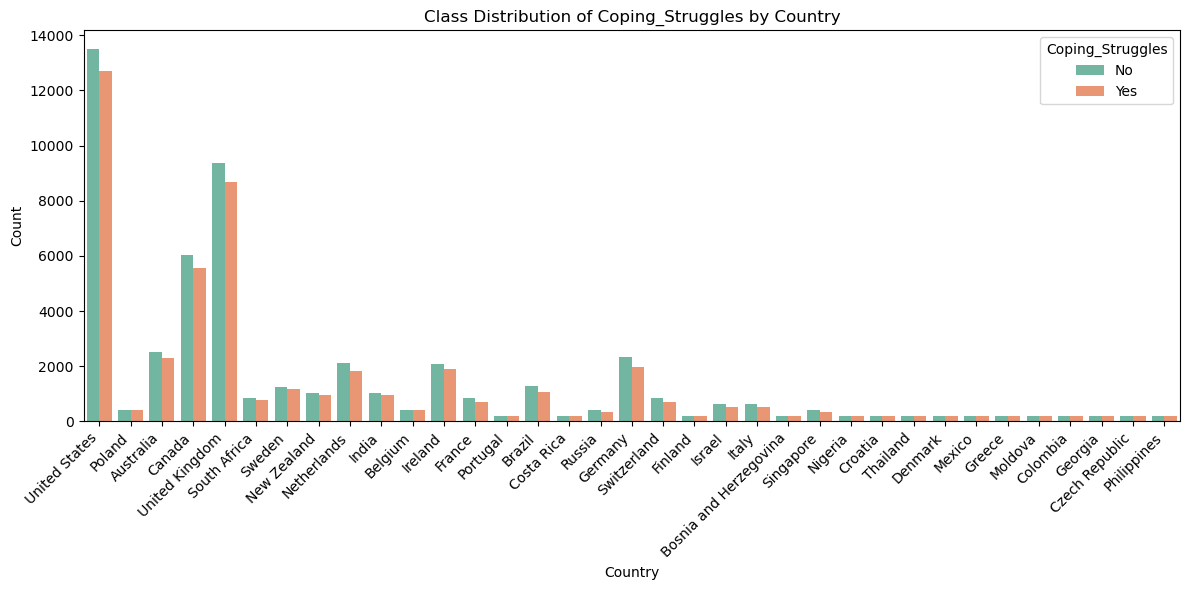

In [58]:
# Plot the class distribution of 'Coping_Struggles' by 'Country'
plt.figure(figsize=(12, 6))  # Adjust the figure size for better readability
sns.countplot(x='Country', hue='Coping_Struggles', data=mental, palette='Set2')

# Add labels and title
plt.title('Class Distribution of Coping_Struggles by Country')
plt.xlabel('Country')
plt.ylabel('Count')

# Add a legend
plt.legend(title='Coping_Struggles', labels=['No', 'Yes'])

# Rotate x-axis labels for better readability (if needed)
plt.xticks(rotation=45, ha='right')

# Display the plot
plt.tight_layout()
plt.show()

The Coping Struggles variable indicates whether an individual faces difficulties with coping mechanisms. From the plot, we observe that the United States has the highest number of individuals struggling with coping, highlighting a crucial mental health concern. They are followed closely by individuals in the UK and Canada.

To better understand the factors contributing to these struggles, we explore employment status, as it may play a significant role in mental health and coping abilities. to access what can be vital or what can cause these difficulties in coping with stuggles make us want to know about employment status

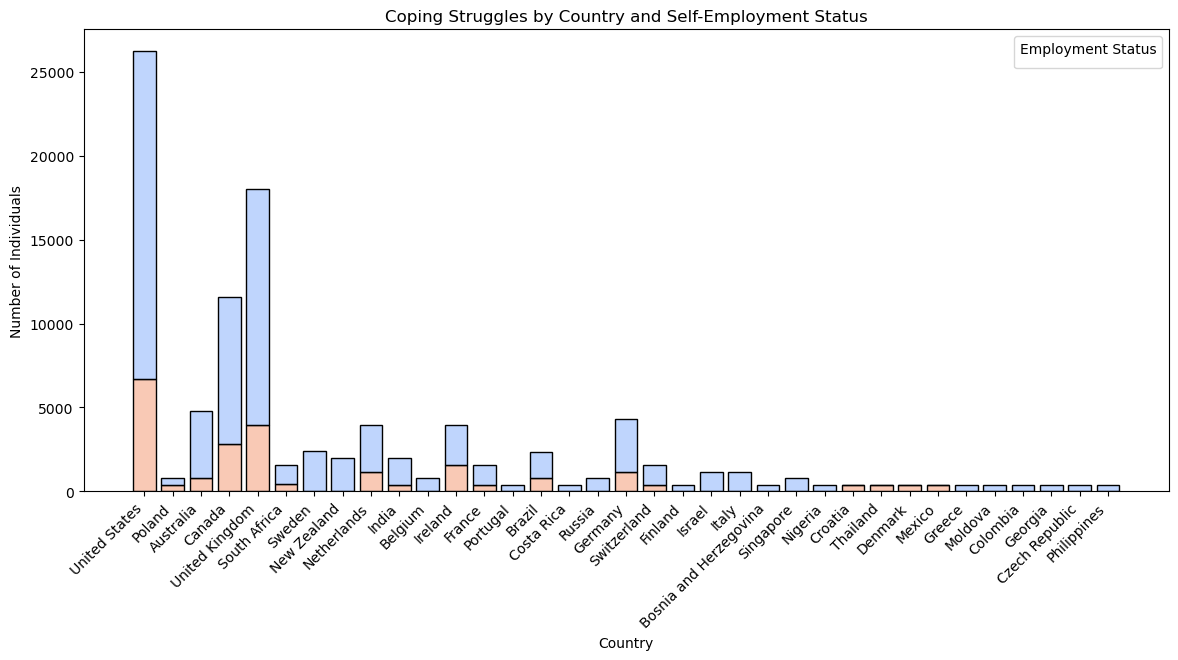

In [59]:
plt.figure(figsize=(14, 6))

# Create a stacked bar plot for Coping Struggles by Country and Self-Employment
ax = sns.histplot(
    data=mental, x="Country", hue="self_employed",
    multiple="stack", palette="coolwarm", shrink=0.8
)

# Improve title and labels for better understanding
plt.title("Coping Struggles by Country and Self-Employment Status")
plt.xlabel("Country")
plt.ylabel("Number of Individuals")

# Rotate x-axis labels for better readability
plt.xticks(rotation=45, ha='right')

# Get legend labels and manually set them to be more descriptive
handles, labels = ax.get_legend_handles_labels()
new_labels = ["Not Self-Employed", "Self-Employed"]  # Clearer labels
plt.legend(handles, new_labels, title="Employment Status", loc="upper right")

# Show the plot
plt.show()


## **Coping Struggles by Country and Employment Status**

### **Summary of Insights**
- The **United States** has the highest number of individuals struggling with coping mechanisms, followed by the **United Kingdom** and **Canada**.
- The **stacked bar plot** shows the distribution of **self-employed** and **non-self-employed** individuals across different countries.
- The **majority** of individuals reporting coping struggles are **not self-employed**, but a significant proportion of self-employed individuals also face challenges.
- Countries with higher **self-employment rates** seem to have **lower coping struggles**, indicating possible job stability factors.
- Further investigation is needed to assess how **employment security** and **mental health support** vary across countries.

### **Key Takeaways**
- The correlation between **employment type** and **coping struggles** suggests that **job stability and economic factors** may influence mental health.
- The highest proportion of individuals struggling with coping is found in countries with larger populations and possibly higher work-related stress.
- **Policy recommendations** could focus on **mental health programs for both employed and self-employed individuals**, with special emphasis on countries showing the highest struggles.



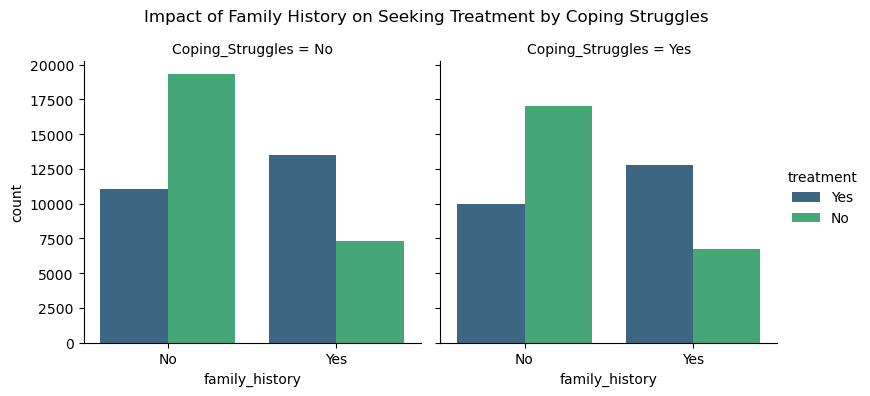

In [60]:
# Create a categorical plot with subplots based on Coping_Struggles
sns.catplot(
    x="family_history", hue="treatment", col="Coping_Struggles",
    data=mental, kind="count", palette="viridis", height=4, aspect=1
)

# Adjust layout and add title
plt.subplots_adjust(top=0.85)
plt.suptitle("Impact of Family History on Seeking Treatment by Coping Struggles")

plt.show()




- Individuals **without coping struggles** and no **family history** of mental illness are less likely to seek treatment.  
- Those **with a family history** are more inclined to seek treatment, but the effect is more pronounced in individuals **without coping struggles**.  
- Among those **struggling with coping**, the gap between seeking and not seeking treatment is narrower, suggesting that coping difficulties may act as a barrier to seeking help.  
- The trend is consistent across both groups, emphasizing the combined impact of **family history** and **coping struggles** on mental health treatment decisions.  


# checking the impact of stress

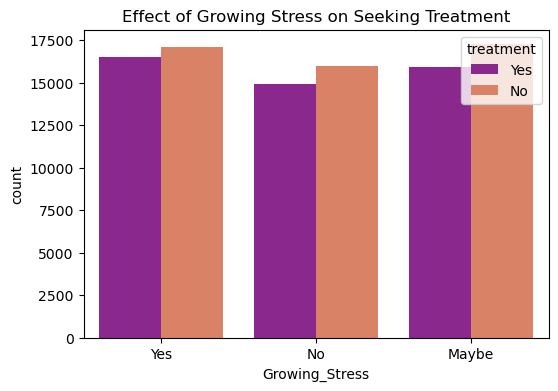

In [61]:
plt.figure(figsize=(6, 4))
sns.countplot(x="Growing_Stress", hue="treatment", data=mental, palette="plasma")
plt.title("Effect of Growing Stress on Seeking Treatment")
plt.show()


Individuals experiencing stress are generally more likely to seek treatment.However, some stressed individuals may still choose not to seek help.A significant proportion of those who are stressed require treatment.Previous plots highlighted employment status as a key factor in coping struggles, suggesting that stress could also play a crucial role in mental health considerations.

# Gender versus seeking treatment

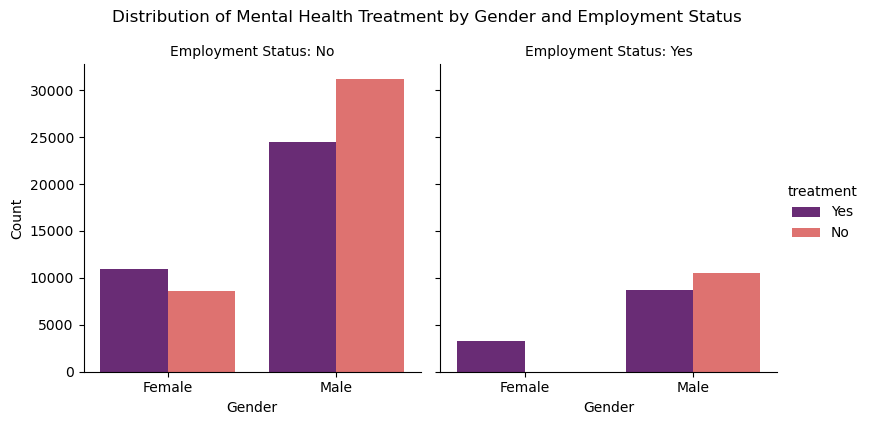

In [62]:
# Create a categorical plot with employment status as a column
g = sns.catplot(
    data=mental, x="Gender", hue="treatment", col="self_employed",
    kind="count", palette="magma", height=4, aspect=1
)

# Set plot labels and title
g.set_axis_labels("Gender", "Count")
g.set_titles("Employment Status: {col_name}")
g.fig.suptitle("Distribution of Mental Health Treatment by Gender and Employment Status", y=1.05)

# Adjust layout and show the plot
plt.show()



### Employment Status and Mental Health Treatment

#### **1. Non-Employed Individuals (Left Plot)**
- A higher proportion of **men** seek treatment compared to women.
- However, a larger number of men also **do not** seek treatment, indicating mixed mental health awareness among men.
- Women in this category have a relatively lower number seeking treatment.

#### **2. Employed Individuals (Right Plot)**
- The number of people seeking treatment is **lower** compared to non-employed individuals.
- Among employed individuals, **men** still have a slightly higher tendency to seek treatment than women.
- The gender gap in seeking treatment is **less pronounced** than in non-employed individuals.

### **Key Insights**
- **Employment status influences treatment-seeking behavior**: Non-employed individuals are more likely to seek treatment than employed ones.
- **Men appear more likely to seek treatment overall**, possibly due to their higher representation in the workforce.
- **Self-employed individuals may experience different stressors** that affect their decision to seek mental health treatment.



# Days spent indoors

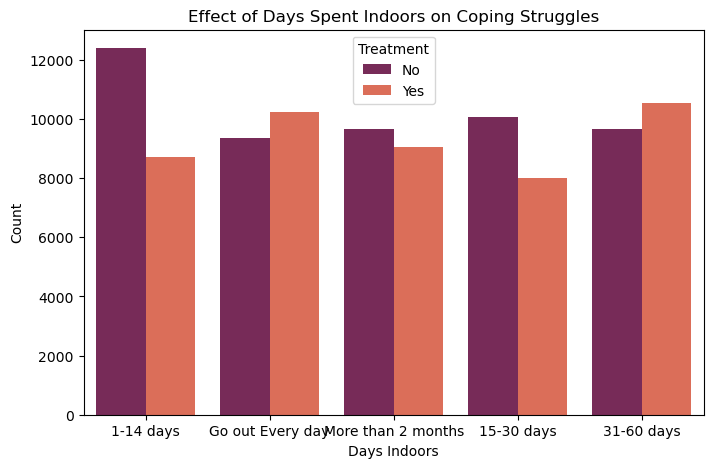

In [63]:
plt.figure(figsize=(8, 5))
sns.countplot(x="Days_Indoors", hue="Coping_Struggles", data=mental, palette="rocket")
plt.title("Effect of Days Spent Indoors on Coping Struggles")
plt.xlabel("Days Indoors")
plt.ylabel("Count")
plt.legend(title="Treatment", labels=["No", "Yes"])
plt.show()


## Effect of Days Spent Indoors on Coping Struggles  

### Key Insights:  
- Individuals who spent **1-14 days indoors** had the **highest proportion of people not seeking treatment**, suggesting that short indoor periods may have a lesser impact on coping struggles.  
- Those who **go out every day** show a more balanced distribution between seeking and not seeking treatment, indicating the **positive influence of social interaction** on mental well-being.  
- **Longer indoor durations (31-60 days)** show a **higher proportion of individuals seeking treatment**, reinforcing the idea that **prolonged isolation may increase mental health struggles**.  
- The trend indicates that as **indoor duration increases, the likelihood of seeking treatment also rises**, emphasizing the negative effects of extended isolation.  

### Key Takeaway:  
Maintaining **social interaction and outdoor activities** can be **crucial for mental well-being**, as **prolonged isolation may contribute to increased struggles and the need for mental health support**.  


# Data Preparation

In [64]:
mental.columns

Index(['Gender', 'Country', 'Occupation', 'self_employed', 'family_history',
       'treatment', 'Days_Indoors', 'Growing_Stress', 'Changes_Habits',
       'Mental_Health_History', 'Mood_Swings', 'Coping_Struggles',
       'Work_Interest', 'Social_Weakness', 'mental_health_interview',
       'care_options'],
      dtype='object')

In [65]:
# viewing variables which are categorical
mental_cat=mental.select_dtypes(include=["object"])
mental_cat.head(3)

,Gender,Country,Occupation,self_employed,family_history,treatment,Days_Indoors,Growing_Stress,Changes_Habits,Mental_Health_History,Mood_Swings,Coping_Struggles,Work_Interest,Social_Weakness,mental_health_interview,care_options
0,Female,United States,Corporate,No,No,Yes,1-14 days,Yes,No,Yes,Medium,No,No,Yes,No,Not sure
1,Female,United States,Corporate,No,Yes,Yes,1-14 days,Yes,No,Yes,Medium,No,No,Yes,No,No
2,Female,United States,Corporate,Yes,Yes,Yes,1-14 days,Yes,No,Yes,Medium,No,No,Yes,No,Yes


In [66]:
for col in mental_cat.columns:  
    print(f"{col}: {mental_cat[col].unique()}\n")


Gender: ['Female' 'Male']

Country: ['United States' 'Poland' 'Australia' 'Canada' 'United Kingdom'
 'South Africa' 'Sweden' 'New Zealand' 'Netherlands' 'India' 'Belgium'
 'Ireland' 'France' 'Portugal' 'Brazil' 'Costa Rica' 'Russia' 'Germany'
 'Switzerland' 'Finland' 'Israel' 'Italy' 'Bosnia and Herzegovina'
 'Singapore' 'Nigeria' 'Croatia' 'Thailand' 'Denmark' 'Mexico' 'Greece'
 'Moldova' 'Colombia' 'Georgia' 'Czech Republic' 'Philippines']

Occupation: ['Corporate' 'Student' 'Business' 'Housewife' 'Others']

self_employed: ['No' 'Yes']

family_history: ['No' 'Yes']

treatment: ['Yes' 'No']

Days_Indoors: ['1-14 days' 'Go out Every day' 'More than 2 months' '15-30 days'
 '31-60 days']

Growing_Stress: ['Yes' 'No' 'Maybe']

Changes_Habits: ['No' 'Yes' 'Maybe']

Mental_Health_History: ['Yes' 'No' 'Maybe']

Mood_Swings: ['Medium' 'Low' 'High']

Coping_Struggles: ['No' 'Yes']

Work_Interest: ['No' 'Maybe' 'Yes']

Social_Weakness: ['Yes' 'No' 'Maybe']

mental_health_interview: ['No' 'Maybe

## Data Preprocessing Encoding

Before training the model, categorical variables in the dataset were encoded to ensure proper numerical representation. The encoding process was done systematically based on the nature of each categorical variable.  

### 1. Binary Encoding  
Binary categorical variables were converted into numerical values, where **‘Yes’ was mapped to 1 and ‘No’ to 0**. The following columns were transformed using this approach:  

- **Self-Employment (`self_employed`)**  
- **Family History of Mental Health Issues (`family_history`)**  
- **Seeking Treatment (`treatment`)**  
- **Coping Struggles (`Coping_Struggles`)**  

### 2. Ordinal Encoding  
For ordinal categorical variables, **values were mapped based on their order of significance**:  

- **Mood Swings (`Mood_Swings`)**:  
  - Low → 0  
  - Medium → 1  
  - High → 2  

- **Gender (`Gender`)**:  
  - Male → 0  
  - Female → 1  

- **Care Options (`care_options`)**:  
  - No → 0  
  - Not Sure → 1  
  - Yes → 2  

### 3. Label Encoding for Nominal Variables  
**Country (`Country`)** and **Occupation (`Occupation`)** were transformed using **Label Encoding**, which assigns unique numerical labels to each distinct category.  

### 4. Multi-Class Encoding  
For categorical variables with three possible responses (**No, Maybe, Yes**), a **numerical mapping** was applied:  

- **No → 0**  
- **Maybe → 1**  
- **Yes → 2**  

This approach was applied to:  

- Growing Stress  
- Changes in Habits  
- Mental Health History  
- Work Interest  
- Social Weakness  
- Mental Health Interview  

### 5. Encoding `Days_Indoors`  
The `Days_Indoors` variable represents the number of days an individual has spent indoors. It was converted into a **numerical scale** based on approximate durations:  

- **Go out Every day** → 0  
- **1-14 days** → 7  
- **15-30 days** → 22  
- **31-60 days** → 45  
- **More than 2 months** → 75  

This transformation ensures that the variable is interpreted **as a numerical duration** rather than a categorical

In [67]:
### 1- BINARY VARIABLES:
binary_columns = [
    'self_employed', 'family_history', 'treatment', 'Coping_Struggles'
]

# Convert 'Yes' to 1, 'No' to 0
for col in binary_columns:
    mental_cat[col] = mental_cat[col].map({'Yes': 1, 'No': 0})


In [68]:
# 2- ORDINAL CATEGORICAL VARIABLES
mood_swing_mapping = {'Low': 0, 'Medium': 1, 'High': 2}
mental_cat['Mood_Swings'] = mental_cat['Mood_Swings'].map(mood_swing_mapping)


In [69]:

gender_mapping = {'Male': 0, 'Female': 1}
mental_cat['Gender'] = mental_cat['Gender'].map(gender_mapping)


# using label encode for country and occupation
encoder_occupation = LabelEncoder()
encoder_country = LabelEncoder()

mental_cat['Occupation'] = encoder_occupation.fit_transform(mental_cat['Occupation'])
mental_cat['Country'] = encoder_country.fit_transform(mental_cat['Country'])


In [70]:
care_options_mapping = {'No': 0, 'Not sure': 1, 'Yes': 2}
mental_cat['care_options'] = mental_cat['care_options'].map(care_options_mapping)


# Multiclass encoding
multiclass = ['Growing_Stress','Changes_Habits','Mental_Health_History', 'Work_Interest','Social_Weakness','mental_health_interview']
for col in multiclass:
    mental_cat[col] = mental_cat[col].map({'No': 0, 'Maybe': 1,'Yes': 2})

In [71]:
# encoding Day indoor to numerical variable
days_indoors_mapping = {
    'Go out Every day': 0,
    '1-14 days': 7,
    '15-30 days': 22,
    '31-60 days': 45,
    'More than 2 months': 75
}

# Apply the mapping to the 'Days_Indoors' column
mental_cat['Days_Indoors'] = mental_cat['Days_Indoors'].map(days_indoors_mapping)


In [73]:
mental_cat.head()

,Gender,Country,Occupation,self_employed,family_history,treatment,Days_Indoors,Growing_Stress,Changes_Habits,Mental_Health_History,Mood_Swings,Coping_Struggles,Work_Interest,Social_Weakness,mental_health_interview,care_options
0,1,34,1,0,0,1,7,2,0,2,1,0,0,2,0,1
1,1,34,1,0,1,1,7,2,0,2,1,0,0,2,0,0
2,1,34,1,1,1,1,7,2,0,2,1,0,0,2,0,2
3,1,34,1,0,1,1,7,2,0,2,1,0,0,2,1,2
4,1,34,1,0,1,1,7,2,0,2,1,0,0,2,0,2


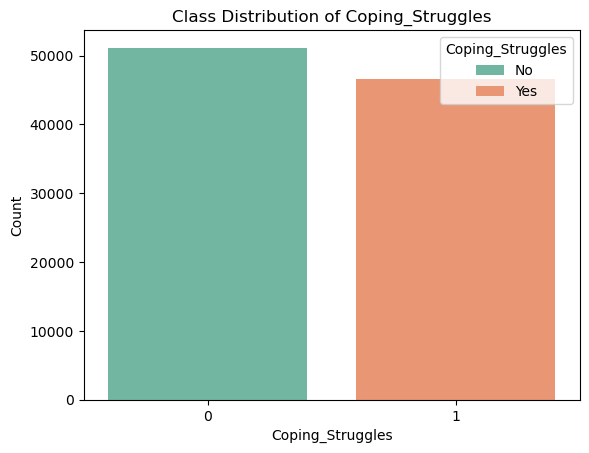

In [74]:
# Plot the class distribution for 'Coping_Struggles'
sns.countplot(x='Coping_Struggles', data=mental_cat, palette='Set2')

# Add labels and title
plt.title('Class Distribution of Coping_Struggles')
plt.xlabel('Coping_Struggles')
plt.ylabel('Count')
plt.legend(labels=['No', 'Yes'], title='Coping_Struggles')
plt.show()


 ### Model Training and Hyperparameter Tuning  

After encoding the categorical variables, the dataset was split into **training (70%) and testing (30%) sets** to ensure a balanced evaluation. The dependent variable (**Coping_Struggles**) was separated from the independent features, and the dataset was shuffled to remove any ordering bias.

#### **Model Selection and Hyperparameter Optimization**  
A diverse range of machine learning models was considered, including:  
- **Linear Models**: Logistic Regression  
- **Tree-Based Models**: Decision Tree, Random Forest  
- **Ensemble Methods**: AdaBoost, Gradient Boosting, XGBoost, LightGBM, and CatBoost  
- **Other Classifiers**: K-Nearest Neighbors (KNN), Support Vector Classifier (SVC), and Naïve Bayes  

Each model was fine-tuned using **GridSearchCV**, which systematically tested multiple hyperparameter combinations across **5-fold cross-validation** to find the optimal configuration. The best models were selected based on their highest accuracy scores during training.  

#### **Results and Performance Evaluation**  
For models with hyperparameter tuning, the **best parameters and scores** were printed, followed by their **test accuracy** on unseen data. Models without a predefined parameter grid were trained directly on the dataset, and their test accuracy was recorded.  

This process helped identify the most effective model for predicting **Coping_Struggles**, ensuring that both performance and generalizability were optimized.


In [75]:
mental_cat_copy = mental_cat.copy()
X = mental_cat_copy.drop(["Coping_Struggles"], axis=1) #independent
y = mental_cat_copy.Coping_Struggles #dependent

In [76]:
# Split the data into training and testing set
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.30, shuffle=True, random_state=101)
print(f"Training set size: {len(X_train)}")
print(f"Test set size: {len(X_test)}")

Training set size: 68406
Test set size: 29317


In [77]:
# Step 1: Store feature names before scaling
feature_names = X.columns.tolist()

In [78]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)


In [79]:
# Define the parameter grids
param_grids = {
    "Random Forest": {
        "n_estimators": [100, 200, 300],
        "max_depth": [None, 10, 20, 30],
        "min_samples_split": [2, 5, 10],
        "min_samples_leaf": [1, 2, 4],
    },
    "Gradient Boost": {
        "n_estimators": [100, 200, 300],
        "learning_rate": [0.01, 0.1, 0.2],
        "max_depth": [3, 4, 5],
    },
    "XGBoost": {
        "n_estimators": [100, 200, 300],
        "learning_rate": [0.01, 0.1, 0.2],
        "max_depth": [3, 4, 5],
    },
}


In [80]:
# different models to evaluate
# Define the models and parameter grids
models = {
    "Logistic Regression": LogisticRegression(),
    "Decision Tree": DecisionTreeClassifier(),
    "Random Forest": RandomForestClassifier(),
    "KNN": KNeighborsClassifier(),
    "SVC": SVC(),
    "Naive Bayes": GaussianNB(),
    "Gradient Boost": GradientBoostingClassifier(),
    "XGBoost": XGBClassifier()
}


In [81]:
# Training and outputting the best model
# Iterate over models and perform GridSearchCV
best_models = {}
for model_name, model in models.items():
    print(f"Training {model_name}...")

    # Get the appropriate param grid for the current model
    param_grid = param_grids.get(model_name)

    # If there's a param grid, run GridSearchCV
    if param_grid:
        grid_search = GridSearchCV(model, param_grid, cv=5, scoring="accuracy", n_jobs=-1, verbose=1)
        grid_search.fit(X_train, y_train)
        
        # Store the best model
        best_models[model_name] = grid_search.best_estimator_

        # Print the best parameters
        print(f"Best parameters for {model_name}: {grid_search.best_params_}")
        print(f"Best score for {model_name}: {grid_search.best_score_}")

        # Evaluate the model on test set
        y_pred = grid_search.best_estimator_.predict(X_test)
        print(f"Test Accuracy for {model_name}: {accuracy_score(y_test, y_pred)}\n")

    else:
        # If no param grid is provided, just fit the model
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)
        print(f"Test Accuracy for {model_name}: {accuracy_score(y_test, y_pred)}\n")

Training Logistic Regression...
Test Accuracy for Logistic Regression: 0.5632227035508408

Training Decision Tree...
Test Accuracy for Decision Tree: 0.992598151243306

Training Random Forest...
Fitting 5 folds for each of 108 candidates, totalling 540 fits
Best parameters for Random Forest: {'max_depth': 20, 'min_samples_leaf': 4, 'min_samples_split': 10, 'n_estimators': 100}
Best score for Random Forest: 0.9941964129498164
Test Accuracy for Random Forest: 0.9933485690896067

Training KNN...
Test Accuracy for KNN: 0.8915305113074325

Training SVC...
Test Accuracy for SVC: 0.8555786744892042

Training Naive Bayes...
Test Accuracy for Naive Bayes: 0.5502609407511

Training Gradient Boost...
Fitting 5 folds for each of 27 candidates, totalling 135 fits
Best parameters for Gradient Boost: {'learning_rate': 0.2, 'max_depth': 5, 'n_estimators': 200}
Best score for Gradient Boost: 0.9952928090722896
Test Accuracy for Gradient Boost: 0.9951905038032541

Training XGBoost...
Fitting 5 folds for


✅ Best Model Saved: Gradient Boost with Accuracy: 0.9952


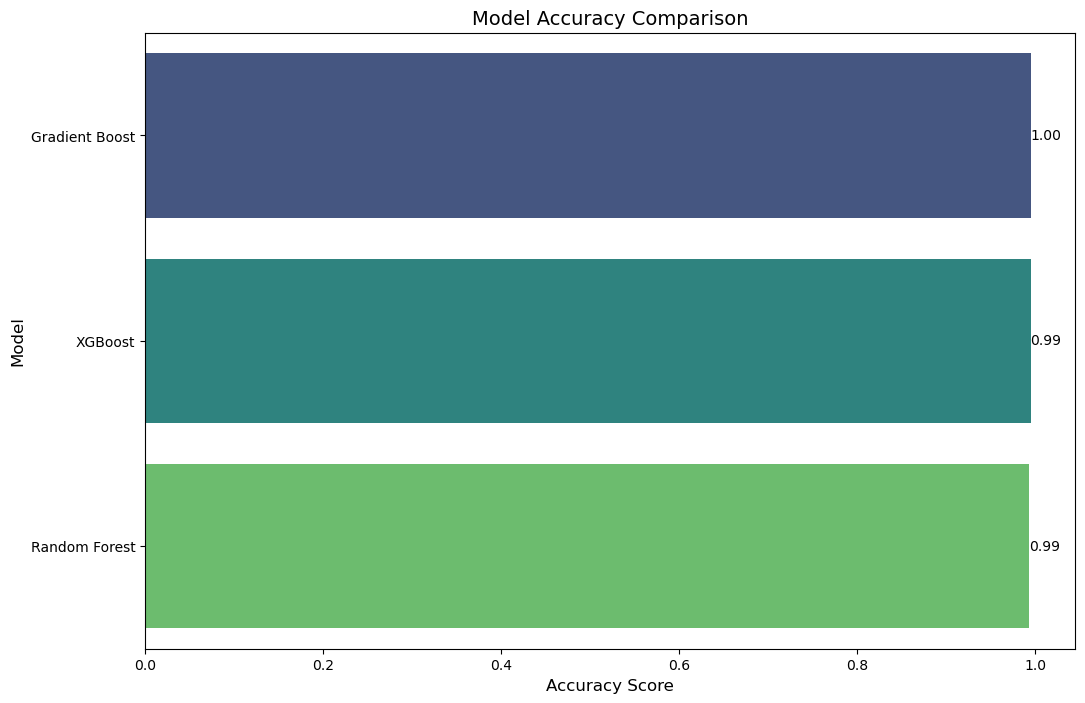

In [84]:
# Store model results
model_results = []
best_model_name = None
best_accuracy = 0

for model_name, model in best_models.items():
    y_pred = model.predict(X_test)
    accuracy = accuracy_score(y_test, y_pred)
    model_results.append({"Model": model_name, "Accuracy Score": accuracy})

    # Identify the best model
    if accuracy > best_accuracy:
        best_accuracy = accuracy
        best_model_name = model_name

# Convert results into a DataFrame
accuracy_df = pd.DataFrame(model_results)

# Sort by Accuracy Score in descending order
accuracy_df = accuracy_df.sort_values(by="Accuracy Score", ascending=False)

# Save the best model
best_model = best_models[best_model_name]

print(f"\n✅ Best Model Saved: {best_model_name} with Accuracy: {best_accuracy:.4f}")

# Plot the accuracies
plt.figure(figsize=(12, 8))
sns.barplot(y="Model", x="Accuracy Score", data=accuracy_df, palette="viridis")

# Add labels
plt.title("Model Accuracy Comparison", fontsize=14)
plt.xlabel("Accuracy Score", fontsize=12)
plt.ylabel("Model", fontsize=12)

# Annotate values on bars
for index, value in enumerate(accuracy_df["Accuracy Score"]):
    plt.text(value, index, f"{value:.2f}", va='center', fontsize=10, color='black')

plt.show()


In [86]:
from sklearn.metrics import classification_report

# Iterate over all trained models and print their classification reports
for model_name, model in best_models.items():
    y_pred = model.predict(X_test)
    
    print(f"\n📌 Classification Report for {model_name}:\n")
    print(classification_report(y_test, y_pred))
    print("=" * 80)  # Separator for better readability



📌 Classification Report for Random Forest:

              precision    recall  f1-score   support

           0       0.99      0.99      0.99     15298
           1       0.99      0.99      0.99     14019

    accuracy                           0.99     29317
   macro avg       0.99      0.99      0.99     29317
weighted avg       0.99      0.99      0.99     29317


📌 Classification Report for Gradient Boost:

              precision    recall  f1-score   support

           0       0.99      1.00      1.00     15298
           1       1.00      0.99      0.99     14019

    accuracy                           1.00     29317
   macro avg       1.00      1.00      1.00     29317
weighted avg       1.00      1.00      1.00     29317


📌 Classification Report for XGBoost:

              precision    recall  f1-score   support

           0       0.99      1.00      1.00     15298
           1       1.00      0.99      0.99     14019

    accuracy                           0.99     2931

100%|===================| 29256/29317 [03:50<00:00]        

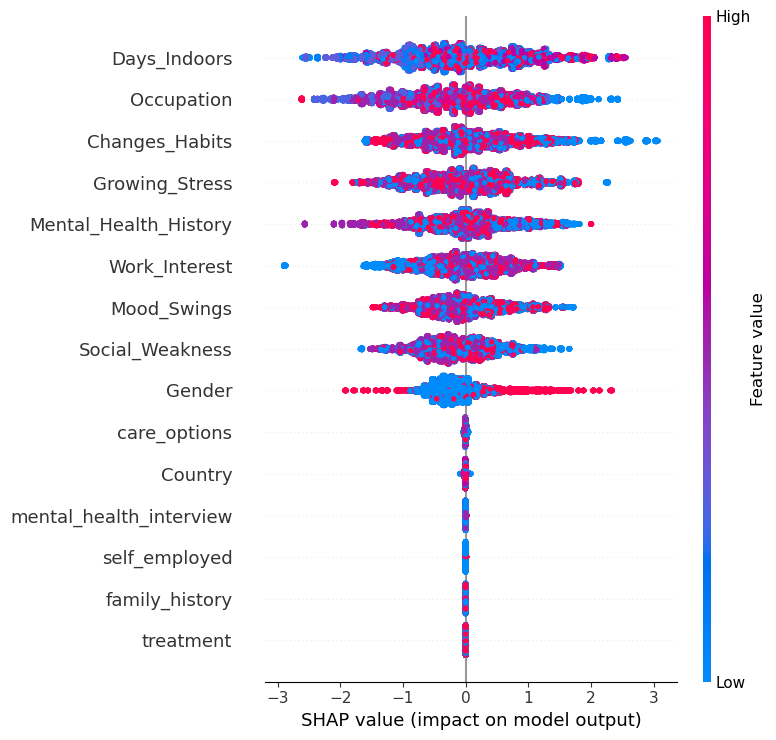

In [89]:
import shap

# Convert X_test1 back to DataFrame to retain feature names
X_test_df = pd.DataFrame(X_test, columns=feature_names)  # Replace 'feature_names' with actual feature list

# Select the best-performing model (you can change this to any model you want to explain)
best_model_name = max(best_models, key=lambda name: accuracy_score(y_test, best_models[name].predict(X_test)))
best_model = best_models[best_model_name]

# Create SHAP explainer
explainer = shap.Explainer(best_model, X_test_df)

# Compute SHAP values
shap_values = explainer(X_test_df)

# Visualize feature importance
shap.summary_plot(shap_values, X_test_df)


# **SHAP Summary Plot Explanation**

This SHAP (SHapley Additive exPlanations) summary plot visualizes the impact of various features on the model's predictions. Each point represents an individual data instance, showing how the feature value affects the model's output.

## **Understanding the Components**
### **1. Features (Y-axis)**
   - The features are listed on the left, such as `Days_Indoors`, `Occupation`, `Growing_Stress`, etc.
   - Features at the top have the highest impact on predictions, while those at the bottom contribute less.

### **2. SHAP Value (X-axis)**
   - The SHAP value represents the impact of a feature on the model’s prediction.
   - **Negative SHAP values:** Push predictions toward *No Struggle*.
   - **Positive SHAP values:** Push predictions toward *Struggle*.
   - The further from zero, the stronger the influence of the feature.

### **3. Color Gradient (Feature Value)**
   - **Red (High Value):** Indicates a high feature value.
   - **Blue (Low Value):** Indicates a low feature value.
   - The distribution helps interpret whether high or low values of a feature contribute more to *Struggle*.

## **Feature Analysis**
### **1. Days_Indoors**
   - This feature is one of the most significant.
   - Higher values (red) are strongly associated with *Struggle*.
   - Lower values (blue) push the prediction toward *No Struggle*.

### **2. Occupation**
   - Different occupations contribute differently to the prediction.
   - Higher occupation levels tend to push the prediction toward *Struggle*.

### **3. Changes_Habits**
   - High changes in habits increase the probability of *Struggle*.
   - If a person has a stable routine, they are less likely to struggle.

### **4. Growing_Stress**
   - This is a strong indicator of struggle.
   - Higher stress levels (red) contribute to the model predicting *Struggle*.

### **5. Mental_Health_History**
   - A history of mental health issues increases the likelihood of struggle.
   - The spread of SHAP values suggests varying degrees of impact.

### **6. Work_Interest**
   - Lower work interest is associated with a higher probability of *Struggle*.
   - Those engaged in their work are less likely to struggle.

### **7. Mood_Swings**
   - Frequent mood swings significantly push predictions toward *Struggle*.
   - Individuals with emotional stability (blue) are less likely to struggle.

### **8. Social_Weakness**
   - Higher values of social weakness (red) increase struggle probability.
   - Socially strong individuals (blue) are more likely to be classified as *No Struggle*.

### **9. Gender**
   - The impact of gender is less clear, but certain values influence predictions.
   - The balanced spread suggests it interacts with other features.

## **Key Takeaways**
- **`Days_Indoors, Growing_Stress, and Mood_Swings` are the strongest predictors of *Struggle*.**
- **Social behavior, work interest, and mental health history also contribute significantly.**
- **Some features like Gender and Country have minimal impact, meaning they do not strongly influence predictions.**


In [98]:
import lime
import lime.lime_tabular

# Convert X_train1 and X_test1 back to DataFrames to retain feature names
X_train_df = pd.DataFrame(X_train, columns=feature_names)  # Replace 'feature_names' with actual feature list
X_test_df = pd.DataFrame(X_test, columns=feature_names)

# Select the best-performing model (you can change this to any model you want to explain)
best_model_name = max(best_models, key=lambda name: accuracy_score(y_test, best_models[name].predict(X_test)))
best_model = best_models[best_model_name]

# Initialize LIME explainer
explainer = lime.lime_tabular.LimeTabularExplainer(
    training_data=X_train_df.values,  
    feature_names=X_train_df.columns.tolist(),
    class_names=['No Struggle', 'Struggle'],  
    mode='classification'
)

# Choose an instance from the test set for explanation
instance_idx = 0  # You can change this index
instance = X_test_df.iloc[instance_idx].values.reshape(1, -1)

# Generate explanation for the selected instance
exp = explainer.explain_instance(instance.flatten(), best_model.predict_proba)

# Show explanation
exp.show_in_notebook()


# **LIME Explanation of Model Prediction**

## **Overview**
This portion explains the Local Interpretable Model-Agnostic Explanations (LIME) visualization for a prediction made by a machine learning model. The goal is to understand why the model classified this instance as "Struggle" and which factors influenced the decision.

 Below is a detailed interpretation for two cases.  

## ** Case 1: Model Predicting No struggle**
### **1️1- Prediction Probabilities**  
- **"No Struggle" → 94%** (Blue): The model strongly predicts this person is **not struggling**.  
- **"Struggle" → 6%** (Orange): Very low probability of struggle.  
- **Conclusion**: The model is **highly confident** in predicting "No Struggle" for this individual.
- 
### **2️2-Feature Contributions (Left Chart)**  
Each feature is **pushing the prediction** towards "No Struggle" (Blue) or "Struggle" (Orange).  

| **Feature**                      | **Effect**                           |  
|----------------------------------|------------------------------------|  
| **Occupation > 0.68**            | Pushes prediction towards "Struggle" (Orange) **(Most influential factor)** |  
| **Social_Weakness < -1.22**      | Pushes prediction towards "No Struggle" (Blue) |  
| **Growing_Stress < -0.03**       | Slightly contributes to "No Struggle" (Blue) |  
| **Changes_Habits < -1.31**       | Pushes towards "No Struggle" |  
| **Mood_Swings > 0.03**           | Very small push towards "No Struggle" |  
| **Work_Interest > 0.09**         | Slightly contributes to "Struggle" |  
| **Days_Indoors < -0.27**         | Pushes towards "No Struggle" |  
| **Self_employed ≤ -0.55**        | Minor effect pushing towards "Struggle" |  

 **Key takeaway**:  
- **"Occupation" is the biggest factor pushing towards "Struggle."**  
- **"Social Weakness" and "Changes in Habits" strongly push towards "No Struggle."**  
- The overall balance of effects explains why the model is **94% confident** in classifying this person as "No Struggle."  

### **3️3-Feature Values (Right Table)**  
This table shows **actual feature values** for this instance.  

| **Feature**                | **Value** |  
|----------------------------|----------|  
| **Occupation**             | 1.40     |  
| **Social Weakness**        | 0.02     |  
| **Growing Stress**         | 1.20     |  
| **Changes in Habits**      | -0.09    |  
| **Mood Swings**            | 1.27     |  
| **Work Interest**          | 1.33     |  
| **Mental Health History**  | 0.05     |  
| **Days Indoors**           | 0.58     |  

 **Key takeaway**:  
- This person's **Occupation (1.40) and Growing Stress (1.20)** are **high**, which aligns with features pushing towards "Struggle."  
- However, **Social Weakness (0.02) and Changes in Habits (-0.09)** are **low**, which supports "No Struggle."  
- The combined effect leads to the **final prediction: "No Struggle" (94%)**.  

### ** Final Summary**  
- **The model predicts "No Struggle" with high confidence (94%)**.  
- **"Occupation" and "Growing Stress" increase the risk of "Struggle."**  
- **"Social Weakness" and "Changes in Habits" are the strongest indicators of "No Struggle."**  
- **Overall, the model balances these factors and strongly favors "No Struggle."**



In [106]:
import numpy as np
import random
import lime.lime_tabular

# Ensure the data is converted to NumPy array for LIME
X_train_array = X_train.to_numpy() if isinstance(X_train, pd.DataFrame) else X_train
X_test_array = X_test.to_numpy() if isinstance(X_test, pd.DataFrame) else X_test

# Select a random instance from the test dataset
random_index = random.randint(0, X_test.shape[0] - 1)
random_instance = X_test_array[random_index].reshape(1, -1)  # Ensure correct shape

# Initialize LIME explainer
explainer = lime.lime_tabular.LimeTabularExplainer(
    training_data=X_train_array,  
    feature_names=X_train_df.columns.tolist(),
    class_names=['No Struggle', 'Struggle'],  
    mode='classification'
)

# Explain the prediction of the randomly selected instance
exp = explainer.explain_instance(random_instance[0], best_model.predict_proba)

# Display the explanation
exp.show_in_notebook()


## **case 2:**

### **Prediction Probabilities**
- **No Struggle** (Class 0) = 0.00
- **Struggle** (Class 1) = 1.00

The model strongly predicts that this individual is struggling with mental health issues.


### **Feature Contributions to the Prediction**
The LIME plot explains how individual features influenced the model's decision.
- **Orange bars** increase the probability of "Struggle."
- **Blue bars** decrease the probability of "Struggle."

| **Feature** | **Value** | **Impact on Mental Health Prediction** |
|------------|----------|-------------------------------------|
| **Occupation** | 1.40 | Higher values suggest occupations linked to mental health struggles (e.g., high-stress jobs). |
| **Mental_Health_History** | 1.27 | A history of mental health issues increases the likelihood of current struggles. |
| **Changes_Habits** | 1.13 | Significant lifestyle changes are often a sign of declining mental well-being. |
| **Social_Weakness** | -1.22 | Lower social weakness (more social connections) reduces mental health struggles. |
| **Days_Indoors** | -1.08 | Spending fewer days indoors suggests better social engagement, reducing the risk of struggles. |
| **Mood_Swings** | 1.27 | Frequent mood swings contribute to mental health instability. |
| **Gender** | 1.81 | Gender may play a role in mental health risks due to societal, biological, or psychological factors. |
| **Growing_Stress** | -0.03 | A low value suggests minimal stress growth, which does not significantly push towards "Struggle." |


### **Summarily**
1. **Occupation and Mental Health History are the strongest contributors to the struggle prediction.**
2. **Social engagement (Social_Weakness, Days_Indoors) acts as a protective factor, reducing mental health struggles.**
3. **Mood Swings and Changes in Habits strongly contribute to mental health deterioration.**
4. **Gender plays a role, but its impact depends on the model's learned patterns from the data.**



# **Conclusion**

This project successfully developed a **mental health prediction model** using **Gradient Boosting**, which outperformed other models in predictive accuracy. The model leveraged behavioral, psychological, and demographic features to determine whether an individual might struggle with mental health.

To ensure transparency and interpretability, we applied **explainability techniques** such as **LIME and SHAP** to analyze how different features influenced predictions.

## **Key Insights**
- **Gradient Boosting** emerged as the best-performing model, demonstrating strong predictive capabilities.  
- **SHAP analysis** revealed that **Growing Stress, Mood Swings, and Changes in Habits** were the most influential factors driving mental health struggles.  
- **Work Interest and Occupation** appeared to have a mitigating effect, suggesting that professional engagement might contribute positively to mental well-being.  
- **LIME explanations** provided localized interpretations, enhancing trust and usability in real-world applications.  

## **Final Thoughts**
This project highlights the effectiveness of **Gradient Boosting** in mental health prediction and the importance of **explainable AI** in sensitive domains. Future improvements could include **temporal analysis** to track mental health trends over time, integrating **causal inference methods**, and expanding the dataset for greater generalization across populations.

By combining **machine learning with explainability**, this research contributes towards more **trustworthy, interpretable, and actionable** mental health analytics.
